# Fine-tuning and Distillation

**Pay a frontier model once for labels, then run a 74M encoder forever. Measured, on a benchmark the student
never saw — and then measured again with a different random seed, which is where it gets interesting.**

`docs/LANDSCAPE.md` calls LLM-as-teacher distillation "the strongest quality-per-dollar point *if you have a
corpus and a stable domain*", and cites NVIDIA's financial-data blueprint where student F1 converges toward the
teacher as the dataset grows. That is a claim about a regime — 10⁵–10⁶ labelled documents — repeated
everywhere without much said about what happens *below* that regime, which is where every project starts.

This notebook runs the small end of it, end to end. Claude Haiku writes an in-domain corpus, labels it in
batches, and `fastino/gliner2.5-small-v1` (74M) is fine-tuned on the result — LoRA and full fine-tune, both.
Four systems are then scored on the same held-out benchmark [notebook 03](03_extractors_head_to_head.ipynb)
used:

| | parameters | labels seen | what it costs to run |
|---|---|---|---|
| gliner2.5-small | 74M | none (zero-shot) | free |
| gliner2.5-base | 194M | none (zero-shot) | free, 2.6× the parameters — §4 measures the wall clock at 1.3× |
| **gliner2.5-small, distilled** | 74M | this notebook's teacher labels | free after training |
| Claude Haiku 4.5 (the teacher) | frontier | — | per token, forever |

The question worth asking is not "does fine-tuning change the number". It is **whether a fine-tuned 74M model
beats an off-the-shelf 194M one**, which is the decision an engineer actually faces, and **how close it gets
to its teacher**, which is the premise of distillation.

Section 5 is the one to read. It trains the same example set nine times — three seeds across three
configurations — because the answer to both questions turns out to depend on which run you would have
reported.

### The measurement has to be honest about leakage

The corpus ships ten documents and a 47-triple answer key. Those are a *test set*. Training on them and then
scoring against their gold facts measures memorisation, and it would produce a beautiful, worthless number.
So the training pool is manufactured separately: the teacher writes short news items about a disjoint
fictional universe — different companies, different people, different sectors — and labels those. The ten
real documents are never seen by any student during training.

Notebook 03's caveat carries forward and bounds everything below. `GOLD_DOC_FACTS` is 47 hand-written
triples and the ten documents contain many more true facts than that, so a triple counted as *spurious* is
often simply true-and-unlabelled. Precision here is a lower bound rather than an estimate, and systems that
emit more triples are penalised for volume as much as for error.

In [1]:
import os, sys, time, json, warnings, shutil, collections
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 44)

import kgx
from kgx.data.documents import DOCUMENTS, GOLD_DOC_FACTS, ALIAS_GROUPS
from kgx.evaluate import score_triples, graph_triples, comparison_table, MatchPolicy
from kgx.llm import ClaudeCLI, LLMExtractor
from kgx import distill

ONT = kgx.BUSINESS_NEWS
LENIENT = MatchPolicy(normalize_names=True, use_aliases=True)
STRICT  = MatchPolicy(normalize_names=True, use_aliases=False)

SMALL = "fastino/gliner2.5-small-v1"     # 74M, the student
BASE  = "fastino/gliner2.5-base-v1"      # 194M, the off-the-shelf model to beat
RUNS  = ROOT / "output" / "distill"

print(f"benchmark  {len(DOCUMENTS)} documents, {len(GOLD_DOC_FACTS)} gold triples, {len(ALIAS_GROUPS)} alias groups")
print(f"ontology   {len(ONT.entities)} entity types, {len(ONT.relations)} relation types")
print(f"seeds      {len(distill.SEEDS)} disjoint fictional universes for the training pool")

import torch
print(f"\ntorch {torch.__version__}  cuda={torch.cuda.is_available()}  mps={torch.backends.mps.is_available()}")
print("gliner2's trainer has no MPS branch: on this machine training runs on CPU.")

benchmark  10 documents, 47 gold triples, 13 alias groups
ontology   13 entity types, 15 relation types
seeds      8 disjoint fictional universes for the training pool



torch 2.13.0  cuda=False  mps=True
gliner2's trainer has no MPS branch: on this machine training runs on CPU.


## 1. Manufacturing an unlabelled pool

Real distillation starts with a warehouse of unlabelled in-domain text and a budget. This sandbox has ten
documents, all of which are the test set, so the pool has to be written. Eight prompts, each naming a sector
and three invented firms, ask for five short items apiece. All eight parse on this run, and the loop still
guards `result.json()` per seed: truncated JSON is the ordinary failure mode of asking for five documents in
one reply, and one bad response should cost you five documents rather than the whole pool.

This is a compromise and it is worth naming: the teacher is labelling prose the same model family wrote, so
the text is easier for it than a real filing would be, and the labels are correspondingly cleaner than they
would be in production. It inflates the *fidelity* number in §4 and has no effect on the benchmark number,
which is measured on human-written documents the students never saw.

In [2]:
llm = ClaudeCLI(model="haiku")
print("claude CLI:", llm.check())
print(f"cache: {llm.cache_dir} ({len(list(llm.cache_dir.glob('*.json')))} responses)")

t0 = time.time()
generated = llm.batch([distill.synth_prompt(s, ONT, n=5) for s in distill.SEEDS], workers=4)
pool = []
for i, result in enumerate(generated):
    try:
        pool += distill.parse_documents(result.json(), i)
    except ValueError as exc:
        print(f"  seed {i} returned unusable JSON: {exc}")

print(f"\n{len(pool)} documents, {sum(len(d['text'].split()) for d in pool)} words, "
      f"{time.time() - t0:.0f}s wall, {llm.n_calls} live calls / {llm.n_cached} cached")
print(f"\n[{pool[0]['doc_id']}] {pool[0]['title']}")
print(pool[0]["text"][:420], "...")

claude CLI: 2.1.246 (Claude Code)
cache: output/llm_cache (36 responses)

40 documents, 4657 words, 0s wall, 0 live calls / 8 cached

[s00d01] Kestrel Air Group Completes Acquisition of Regional Carrier Assets
Kestrel Air Group announced today that it has successfully acquired the Denver-based regional operations and aircraft portfolio of Horizon Regional Lines, significantly expanding its presence in the western United States market. The transaction, valued at $187 million, includes 23 turboprop aircraft and associated landing rights at twelve regional airports across Colorado, Utah, and Wyoming. Kestrel Air CEO Ruben Alv ...


### Chunking

Training units are one to three sentences. Two reasons, both measured elsewhere in this repo: GLiNER's
relation recall falls off past a few hundred words (notebook 01's length sweep), and a short unit gives the
teacher less room to assert a link between entities that are half a page apart.

In [3]:
chunks = distill.chunk_sentences(pool)
lens = sorted(c.n_words for c in chunks)
print(f"{len(chunks)} chunks from {len(pool)} documents")
print(f"words per chunk: min {lens[0]}, median {lens[len(lens)//2]}, max {lens[-1]}")
for c in chunks[:4]:
    print(f"  [{c.chunk_id}] ({c.n_words}w) {c.text[:96]}")

213 chunks from 40 documents
words per chunk: min 9, median 21, max 43
  [s00d01c00] (31w) Kestrel Air Group announced today that it has successfully acquired the Denver-based regional op
  [s00d01c01] (23w) The transaction, valued at $187 million, includes 23 turboprop aircraft and associated landing r
  [s00d01c02] (20w) Kestrel Air CEO Ruben Alvarez stated that the acquisition strengthens the company's competitive 
  [s00d01c03] (13w) "This strategic move allows us to consolidate operations and achieve meaningful cost synergies,"


### Labelling, twenty chunks per call

Per-call overhead dominates through the CLI: `claude -p` pays a prompt preamble and a subprocess on every
invocation, and the ontology alone is several hundred tokens that would otherwise be re-sent once per chunk.
Twenty chunks to a call turns 213 labelling calls into eleven. The instructions are the same ones
`kgx.llm._ontology_prompt` gives the teacher for a whole document, so the labels are the same function of the
text that the teacher row in §4's scoreboard is measuring — only batched.

In [4]:
BATCH = 20
batches = [chunks[i:i + BATCH] for i in range(0, len(chunks), BATCH)]

t0 = time.time()
responses = llm.batch([distill.label_prompt(b, ONT) for b in batches], workers=4)
labels = {}
for batch, result in zip(batches, responses):
    try:
        labels.update(distill.parse_label_batch(result.json(), batch))
    except ValueError as exc:
        print(f"  a batch returned unusable JSON: {str(exc)[:90]}")

print(f"{len(labels)}/{len(chunks)} chunks labelled in {len(batches)} calls, {time.time() - t0:.0f}s wall")
print(f"llm so far: {llm.stats()}")
print(f"\nteacher cost per labelled chunk: ${llm.total_cost_usd / max(len(labels), 1):.5f}")
print(f"one call per chunk instead of {BATCH} would have been roughly "
      f"{len(chunks) / len(batches):.0f}x the calls for the same tokens of text")

213/213 chunks labelled in 11 calls, 0s wall
llm so far: {'model': 'haiku', 'live_calls': 0, 'cache_hits': 19, 'cost_usd_this_run': 0.0, 'cost_usd_observed': 0.249, 'live_seconds': 0.0, 'mean_latency_ms': 15629}

teacher cost per labelled chunk: $0.00000
one call per chunk instead of 20 would have been roughly 19x the calls for the same tokens of text


`ClaudeCLI` only accumulates `cost_usd` on live calls, so on a warm cache the per-chunk figure above prints
as zero. The billed cost is stored in each cached response and section 6 reads it back from there — that is
the number to use.

## 2. From LLM output to trainable supervision

This is the step that decides whether the whole exercise works, and it is the step every tutorial skips.

GLiNER2.5 is a span extractor. Its supervision is *offsets*, not strings. A teacher label whose surface form
is not literally in the text is not a training example — and the failure is not graceful.

In [5]:
demo = "Dana Okonjo, Bluewater's board chair, said the Denver-based lessor would not divest."
print(demo, "\n")
display(pd.DataFrame([
    {"teacher label": label,
     "substring? (what validate() checks)": label.lower() in demo.lower(),
     "token-aligned span": distill.occurrence(label, demo),
     "usable after snapping": distill.occurrence(label, demo) or distill.snap_span(label, demo)}
    for label in ["Dana Okonjo", "Denver", "Bluewater Aviation Holdings", "divestiture"]
]).set_index("teacher label"))

Dana Okonjo, Bluewater's board chair, said the Denver-based lessor would not divest. 



,substring? (what validate() checks),token-aligned span,usable after snapping
teacher label,,,
Dana Okonjo,True,Dana Okonjo,Dana Okonjo
Denver,True,NaN,NaN
Bluewater Aviation Holdings,False,NaN,Bluewater
divestiture,False,NaN,NaN


`"Denver"` is the one worth staring at. It **is** a case-insensitive substring of `"Denver-based"`, so
`TrainingDataset.validate()` passes it and `validate_data=True` sanitises nothing. The boundary preprocessor
aligns gold mentions to *tokens*, disagrees, and raises

```
ValueError: entity 'geography' was not found in sample 2
```

from inside the collator, part-way into an epoch — that traceback is what an earlier draft of this notebook
produced, before `kgx.distill` started checking with the stricter rule up front. The validator's rule is looser
than the preprocessor's rule, so a dataset that validates clean can still kill the run.

`"Bluewater Aviation Holdings"` is the more interesting failure, because the teacher is not wrong. It
resolved the short form on the way out — which is exactly what you want in a knowledge graph and exactly
what you cannot supervise a span model with. `snap_span` takes the longest word-prefix of the label that
does occur, so the label becomes `"Bluewater"` and the example survives.

In [6]:
repairs = []
examples, records, stats = distill.to_examples(
    chunks, labels, ONT, negatives=None, repairs=repairs)

display(pd.DataFrame([stats.as_record()]).T.rename(columns={0: "count"}))
print(f"\nrepairs by prefix-snapping ({len(repairs)}), first few:")
for _, before, after in repairs[:6]:
    print(f"  {before!r} -> {after!r}")

,count
chunks labelled,213
chunks with no facts,27
entity labels,496
entity kept,434
entity repaired by snapping,10
entity dropped: unknown type,0
entity dropped: span not in text,62
relation labels,235
relation kept,142
relation dropped: unknown name,0



repairs by prefix-snapping (10), first few:
  'Verdant Chemical Works' -> 'Verdant'
  'Verdant Chemical Works' -> 'Verdant'
  'Steadfast Coatings Ltd.' -> 'Steadfast'
  'North America' -> 'North'
  'Fairhaven Surgical' -> 'Fairhaven'
  'Thistledown Power' -> 'Thistledown'


### Negatives, and the one the API cannot express

An `InputExample` whose `entities` dict lists a type with an **empty** list is not ignored — GLiNER2.5 turns
it into a real query with zero gold spans. That is the only mechanism for teaching the model to stay silent
about a type, and it matters here: at inference the schema carries all 13 entity types at once, so a model
trained only on the two or three types present in each chunk has never seen the prompt it will be asked.
Every example below declares all 13. That reasoning is sound and defensible in advance, and §5 measures it:
declaring all 13 comes last of the three settings there — decisively so on fidelity, and by less than the
seed noise on the benchmark.

Relations have no equivalent. A `Relation` needs a head and a tail to serialise, and a bare
`Relation("acquires")` fails validation with *"has no fields"*. So the 15 relation types get positive
supervision only, and the schema the model sees during training is always smaller than the one it sees at
inference.

In [7]:
from gliner2 import AutoExtractor
from gliner2.training import InputExample, Relation, TrainingDataset
from gliner2.training.trainer import ExtractorCollator

probe = AutoExtractor.from_pretrained(SMALL)
probe.processor.change_mode(is_training=True)
collator = ExtractorCollator(probe.processor, is_training=True,
                             architecture="boundary", max_gold_per_query=64)

print(f"{SMALL}: architecture={probe.architecture}, "
      f"{sum(p.numel() for p in probe.parameters()):,} params, "
      f"enable_relations={probe.enable_relations}")

ex = examples[next(i for i, r in enumerate(records) if r["triples"])]
batch = collator([(ex.text, ex.to_dict()["output"])])
queries = [(q.task_type, q.task_name, q.role_name) for q in batch.query_layouts[0].queries]
print(f"\nexample declares {sum(1 for v in ex.entities.values() if v)} populated entity types "
      f"and {sum(1 for v in ex.entities.values() if not v)} empty ones")
print(f"collator built {len(queries)} queries -> empty types ARE supervised:")
print("  ", queries[:6], "...")
print("edge targets present:", batch.targets.edge_targets is not None)

print("\nbare Relation('acquires') as a negative:",
      TrainingDataset([InputExample(text=ex.text, entities={"company": []},
                                    relations=[Relation("acquires")])]
                      ).validate(raise_on_error=False)["errors"])

fastino/gliner2.5-small-v1: architecture=boundary, 73,881,879 params, enable_relations=True

example declares 2 populated entity types and 11 empty ones
collator built 17 queries -> empty types ARE supervised:
   [('relations', 'operates_in', 'head'), ('relations', 'operates_in', 'tail'), ('entities', 'entities', 'company'), ('entities', 'entities', 'geography'), ('entities', 'entities', 'person'), ('entities', 'entities', 'regulator')] ...
edge targets present: True

bare Relation('acquires') as a negative: ["Example 0: Relation 'acquires' has no fields"]


### The processor rewrites your schema on every batch

Collating the *same* example twice does not give the same thing twice. The training-mode processor shuffles
task order, sometimes drops the relation task entirely, and sometimes replaces the entity type names with
`entity 1`, `entity 2`. That is deliberate augmentation — it is why gliner2.5 tolerates arbitrary label
phrasings at inference — but it is worth seeing before you conclude your data is corrupt.

In [8]:
shapes = collections.Counter()
payload = ex.to_dict()["output"]
for _ in range(40):
    b = collator([(ex.text, payload)])
    shapes[tuple(f"{q.task_type}:{q.role_name}" for q in b.query_layouts[0].queries)] += 1

variants = collections.Counter()
for shape, count in shapes.items():
    variants[(any(s.startswith("relations") for s in shape),
              any("entity " in s for s in shape),
              len(shape))] += count
display(pd.DataFrame(
    [{"of 40 collations": c, "relation task kept": rel,
      "type names anonymised": anon, "queries built": n}
     for (rel, anon, n), c in sorted(variants.items(), key=lambda kv: -kv[1])]
))
del probe, collator

,of 40 collations,relation task kept,type names anonymised,queries built
0,17,True,False,17
1,11,True,False,15
2,7,True,True,17
3,3,True,True,15
4,2,False,False,13


### Split by document, not by chunk

Two chunks from the same generated item share names, sector and phrasing. Splitting on chunks would put
near-duplicates on both sides of the wall and make the held-out fidelity score meaningless. The split is by
source document: every fifth item is held out whole.

In [9]:
doc_ids = sorted({r["doc_id"] for r in records})
held_out_docs = {d for i, d in enumerate(doc_ids) if i % 5 == 4}

train_examples = [e for e, r in zip(examples, records) if r["doc_id"] not in held_out_docs]
eval_examples  = [e for e, r in zip(examples, records) if r["doc_id"] in held_out_docs]
held_records   = [r for r in records if r["doc_id"] in held_out_docs]
held_gold      = [t for r in held_records for t in r["triples"]]

print(f"pool documents      {len(doc_ids)}  ({len(held_out_docs)} held out)")
print(f"train examples      {len(train_examples)}")
print(f"held-out examples   {len(eval_examples)}  carrying {len(held_gold)} teacher triples")
print(f"train triples       {sum(len(r['triples']) for r in records) - len(held_gold)}")

hist = collections.Counter(t[1] for r in records for t in r["triples"])
display(pd.DataFrame(hist.most_common(), columns=["relation", "teacher labels"]).set_index("relation").T)
print(f"\n{len(ONT.relations) - len(hist)} of {len(ONT.relations)} relation types got no supervision at all:",
      ", ".join(sorted({r.name for r in ONT.relations} - set(hist))) or "none")

pool documents      40  (8 held out)
train examples      170
held-out examples   43  carrying 26 teacher triples
train triples       116


relation,operates_in,officer_of,produces,acquires,faces_risk,reports_metric,has_stake_in,competes_with,partners_with,subject_to,subsidiary_of,supplies,participant_in
teacher labels,33,25,15,13,13,13,7,5,5,4,3,3,3



2 of 15 relation types got no supervision at all: impacts, party_to


## 3. Fine-tuning

Two runs, same data, same schedule. LoRA on the encoder plus every task head, and a full fine-tune of all
74M parameters. Running both is not thoroughness for its own sake: if only LoRA were run and it failed to
help, the obvious objection would be "you only trained 2% of the weights". The full fine-tune closes that.

Six settings below are load-bearing. Five of them are defaults that would quietly ruin the run; the
sixth is a default worth knowing you must not change:

| setting | shipped default | why it matters |
|---|---|---|
| `fp16=False, bf16=False` | `None` → auto | `None` becomes `fp16=True`, and boundary models then force `bf16` — which raises on Apple Silicon |
| `eval_strategy="epoch"` | `"steps"` / 500 | a few-hundred-step run would never evaluate, never save `best`, and report `best_metric = inf` |
| `logging_steps=1` | `1` | already correct — raise it and `train_metrics_history` comes back empty, so `history[0]` raises `IndexError` |
| `on_capacity_exceeded="truncate_with_warning"` | `"raise"` | more than `max_gold_per_query=64` gold spans on one query aborts the run |
| `num_workers=0, pin_memory=False` | `4`, `True` | forced to 0 on darwin anyway; pinning is pointless on CPU |
| `lora_target_modules=[...]` | span-architecture names | see below |

The default `lora_target_modules` deserves its own paragraph.

In [10]:
from gliner2.training import ExtractorTrainer, TrainingConfig
from gliner2.training.lora_targets import _resolve_targets

model_probe = AutoExtractor.from_pretrained(SMALL)
DEFAULT_TARGETS = TrainingConfig().lora_target_modules
NEUTRAL_TARGETS = ["encoder", "extractive_head", "relation_head",
                   "classification_head", "record_head"]

rows = []
for name, targets in [("gliner2 default", DEFAULT_TARGETS), ("architecture-neutral", NEUTRAL_TARGETS)]:
    hit = _resolve_targets(model_probe, targets)
    rows.append({"targets": name, "Linear modules": len(hit),
                 "from boundary_head": sum(x.startswith("boundary_head") for x in hit),
                 "from relation_scorer": sum(x.startswith("relation_scorer") for x in hit)})
display(pd.DataFrame(rows).set_index("targets"))
print("task modules on this checkpoint:", model_probe.task_module_names())
del model_probe

,Linear modules,from boundary_head,from relation_scorer
targets,,,
gliner2 default,74,0,0
architecture-neutral,131,43,6


task modules on this checkpoint: ('classifier', 'boundary_head', 'record_decoder', 'relation_scorer')


The shipped default names heads that belong to the *span* architecture. On a gliner2.5 boundary checkpoint it
resolves to encoder layers only — the relation scorer stays frozen. You would train for a minute, get a
model whose entity extraction moved and whose relations did not, and have no error message to explain it.
Relation distillation is the entire point here, so the neutral aliases are used.

In [11]:
LORA_R, EPOCHS, BATCH_SIZE = 16, 8, 4
BASE_CFG = dict(
    num_epochs=EPOCHS, batch_size=BATCH_SIZE, eval_batch_size=8,
    encoder_lr=1e-5, task_lr=5e-4,
    eval_strategy="epoch",                        # default "steps"/500 never fires here
    logging_steps=1,                              # keeps train_metrics_history populated
    num_workers=0, pin_memory=False,              # darwin forces 0 anyway
    fp16=False, bf16=False,                       # required: see the table above
    validate_data=True,
    on_capacity_exceeded="truncate_with_warning",
    save_total_limit=1, seed=42,
)

def fine_tune(name, **extra):
    out = RUNS / name
    if out.exists():
        shutil.rmtree(out)
    model = AutoExtractor.from_pretrained(SMALL)
    cfg = TrainingConfig(output_dir=str(out), experiment_name=name, **BASE_CFG, **extra)
    trainer = ExtractorTrainer(model=model, config=cfg)
    t0 = time.time()
    results, log = distill.quiet_train(trainer, train_examples, eval_examples)
    wall = time.time() - t0
    print(f"── {name}: {wall:.0f}s wall, {results['total_steps']} steps "
          f"({wall / results['total_steps']:.2f}s/step), device={trainer.device}, "
          f"best eval_loss {results['best_metric']:.1f}")
    for line in log:
        print("   ", line.split(" - ")[-1])
    return out, results, wall

lora_dir, lora_res, lora_wall = fine_tune(
    "lora", use_lora=True, lora_r=LORA_R, lora_alpha=2.0 * LORA_R,
    lora_target_modules=NEUTRAL_TARGETS, save_adapter_only=True)

2026-08-26 21:47:36 - INFO - gliner2.training.trainer - Froze all model parameters for LoRA training


2026-08-26 21:47:36 - INFO - gliner2.training.trainer - LoRA setup complete: 1,779,152 trainable / 75,661,031 total (2.35%)


── lora: 66s wall, 336 steps (0.20s/step), device=cpu, best eval_loss 174.7
      Total optimization steps = 336
      LoRA enabled: 1,779,152 trainable / 75,661,031 total (2.35%)
    New best eval_loss: 191.8356
    New best eval_loss: 174.7393


Nothing in that log says `Dropped relation auxiliary loss after ...`. That message is worth grepping for on
every run: `relation_loss` is wrapped in a `try/except (RuntimeError, IndexError, ValueError)` that logs it
once and then sets the term to `None` for the rest of training. A run that hit it looks exactly like a run
that trained fine and simply did not learn relations.

A LoRA run does not write a loadable checkpoint — the directory holds an adapter and nothing else, and
`AutoExtractor.from_pretrained` on it fails with a missing `config.json`. Merge through PEFT first.

Merge `final`, which is the last epoch, written once the loop closes. The trainer also keeps a `best`
directory — the epoch with the lowest held-out loss — and nothing below ever loads it. Every score in this
notebook belongs to the last-epoch weights, and `best_metric` is reported beside them as a property of the
run, not of the model that was scored.

In [12]:
from peft import PeftModel

merged = PeftModel.from_pretrained(
    AutoExtractor.from_pretrained(SMALL), str(lora_dir / "final")).merge_and_unload()
merged.eval()
LORA_MERGED = RUNS / "lora_merged"
merged.save_pretrained(str(LORA_MERGED))
del merged

adapter_files = sorted(p.name for p in (lora_dir / "final").iterdir())
adapter_mb = sum(p.stat().st_size for p in (lora_dir / "final").rglob("*") if p.is_file()) / 1e6
print(f"adapter dir  : {adapter_files}  ({adapter_mb:.1f} MB)")
print(f"merged dir   : {sorted(p.name for p in LORA_MERGED.iterdir())}")

adapter dir  : ['README.md', 'adapter_config.json', 'adapter_model.safetensors']  (7.2 MB)
merged dir   : ['config.json', 'encoder_config', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json']


In [13]:
full_dir, full_res, full_wall = fine_tune("full", use_lora=False)
full_mb = sum(p.stat().st_size for p in (full_dir / "final").rglob("*") if p.is_file()) / 1e6
print(f"full checkpoint: {full_mb:.0f} MB per saved copy "
      f"({sum(p.stat().st_size for p in full_dir.rglob('*') if p.is_file()) / 1e6:.0f} MB written in total)")

2026-08-26 21:48:47 - INFO - gliner2.training.trainer - Using device: cpu


2026-08-26 21:48:47 - INFO - gliner2.training.trainer - LoRA is disabled


── full: 94s wall, 336 steps (0.28s/step), device=cpu, best eval_loss 176.7
      Total optimization steps = 336
    New best eval_loss: 211.8844
    New best eval_loss: 195.5170
    New best eval_loss: 180.3393
    New best eval_loss: 179.1975
    New best eval_loss: 178.2624
    New best eval_loss: 176.6861
full checkpoint: 304 MB per saved copy (912 MB written in total)


### The training curve

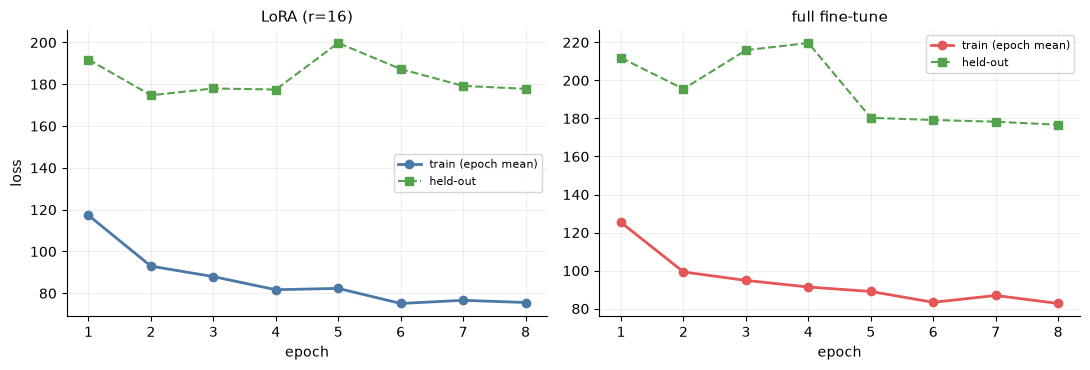

LoRA                 full          
   train_loss eval_loss train_loss eval_loss
ep                                          
1       117.3     191.8      125.3     211.9
2        93.0     174.7       99.3     195.5
3        88.0     178.0       94.9     215.9
4        81.7     177.5       91.4     219.7
5        82.3     199.8       89.0     180.3
6        75.1     187.3       83.3     179.2
7        76.6     179.2       86.9     178.3
8        75.6     177.8       82.7     176.7

In [14]:
import matplotlib.pyplot as plt

lora_curve, full_curve = distill.curve(lora_res), distill.curve(full_res)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
for ax, (name, cv, colour) in zip(axes, [("LoRA (r=16)", lora_curve, "#4C78A8"),
                                         ("full fine-tune", full_curve, "#E45756")]):
    ax.plot(cv.index, cv.train_loss, marker="o", lw=2, color=colour, label="train (epoch mean)")
    ax.plot(cv.index, cv.eval_loss, marker="s", ls="--", color="#54A24B", label="held-out")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("epoch")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
axes[0].set_ylabel("loss")
plt.tight_layout(); plt.show()

display(pd.concat({"LoRA": lora_curve, "full": full_curve}, axis=1).round(1))

Train loss falls by about a third in both runs, 117.3 to 75.6 for LoRA and 125.3 to 82.7 for the full
fine-tune, so the gradient is finding something. Held-out loss moves much less and not monotonically: LoRA's
best epoch is 2, at 174.7, and none of the six epochs after it gets back there — epoch 5 (199.8) is worse
than epoch 1 (191.8). The full fine-tune never gets below 176.7, which it happens to reach on the last
epoch, despite updating every weight. By epoch 8 LoRA's train loss is 75.6 against 177.8 held out. On 170
examples that is what overfitting looks like, and `save_best` is picking between epochs whose eval losses
differ by less than the wobble between them.

Read the direction, not the level. The figure is a sum over proposal, count, relation and classification
terms scored against a schema the processor re-samples on every batch, so it has no scale to be compared
against — and section 5 shows the same thing one level up: across nine runs, the lowest held-out loss does
not pick out the best benchmark score. The per-epoch version of that question is not asked here. Every model
scored below is `final`, the last epoch: for the full fine-tune that is also the `best` checkpoint, and for
LoRA it is epoch 8 while `best` was epoch 2, six epochs of overfitting earlier.

## 4. Two questions, two scoreboards

**Did the student learn the teacher's function?** Score each model against the teacher's own labels on the
held-out chunks. The teacher is 1.0 there by construction, so it is excluded; what this measures is
distillation fidelity, on text drawn from the training distribution. It is reported at two granularities —
typed entity mentions, of which there are enough to mean something, and triples, of which there are not.

**Did that make it a better extractor?** Score each model on the ten real documents against the 47
hand-written gold triples, through the identical resolve-and-assemble pipeline notebook 03 used. Nothing here
was trained on those documents.

The two can disagree, and if they do that is the finding.

In [15]:
from kgx.evaluate import score_entities

# One resolver, reused: `resolve()` is stateless and building it loads a
# sentence-transformer, which is otherwise the slowest thing in this section.
RESOLVER = kgx.EntityResolver(threshold=0.90).learn_aliases(d["text"] for d in DOCUMENTS)

def build(graphs):
    """Resolve and assemble, identically for every system -- notebook 03's pipeline."""
    mentions = [m for g in graphs for m in g.mentions]
    return graph_triples(kgx.build_graph(graphs, RESOLVER.resolve(mentions), ONT))

held_docs      = [{"doc_id": r["chunk_id"], "text": r["text"]} for r in held_records]
held_mentions  = [m for r in held_records for m in r["mentions"]]
print(f"held-out gold from the teacher: {len(held_mentions)} typed mentions, {len(held_gold)} triples")

def evaluate(path):
    """Benchmark + fidelity for one checkpoint, returned as scores."""
    extractor = kgx.GlinerExtractor(path)
    t0 = time.time()
    graphs = extractor.extract_batch(DOCUMENTS, ONT)
    ms = (time.time() - t0) / len(DOCUMENTS) * 1000
    b = score_triples(build(graphs), GOLD_DOC_FACTS, policy=LENIENT, aliases=ALIAS_GROUPS)
    held = extractor.extract_batch(held_docs, ONT)
    fe = score_entities([(m.text, m.type) for g in held for m in g.mentions], held_mentions)
    ft = score_triples([t for g in held for t in g.triples()], held_gold, policy=STRICT)
    del extractor
    return b, fe, ft, ms, graphs

STUDENTS = {
    "gliner2.5-small (74M, zero-shot)": SMALL,
    "gliner2.5-base (194M, zero-shot)": BASE,
    "small + LoRA distil (74M)":        str(LORA_MERGED),
    "small + full-FT distil (74M)":     str(full_dir / "final"),
}

bench, fid_ent, fid_tri, ms_per_doc, edge_counts, mention_counts, pred_rel = {}, {}, {}, {}, {}, {}, {}
for name, path in STUDENTS.items():
    b, fe, ft, ms, graphs = evaluate(path)
    bench[name], fid_ent[name], fid_tri[name], ms_per_doc[name] = b, fe, ft, ms
    edge_counts[name] = sum(len(g.edges) for g in graphs)
    mention_counts[name] = sum(len(g.mentions) for g in graphs)
    pred_rel[name] = collections.Counter(e.type for g in graphs for e in g.edges)
    print(f"{name:34} benchmark F1 {b.f1:.3f}   fidelity: mentions {fe.f1:.3f}, triples {ft.f1:.3f}")

held-out gold from the teacher: 94 typed mentions, 26 triples


2026-08-26 21:50:30 - INFO - sentence_transformers.SentenceTransformer - Use pytorch device_name: mps


2026-08-26 21:50:30 - INFO - sentence_transformers.SentenceTransformer - Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


gliner2.5-small (74M, zero-shot)   benchmark F1 0.275   fidelity: mentions 0.464, triples 0.295


The tokenizer you are loading from '/Users/lyonwj/github/johnymontana/extraction-sandbox/output/distill/lora_merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


gliner2.5-base (194M, zero-shot)   benchmark F1 0.330   fidelity: mentions 0.523, triples 0.286


The tokenizer you are loading from '/Users/lyonwj/github/johnymontana/extraction-sandbox/output/distill/full/final' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


small + LoRA distil (74M)          benchmark F1 0.295   fidelity: mentions 0.425, triples 0.310


small + full-FT distil (74M)       benchmark F1 0.242   fidelity: mentions 0.704, triples 0.455


In [16]:
teacher_graphs = LLMExtractor(llm).extract_batch(DOCUMENTS, ONT, workers=4)
bench["Claude Haiku 4.5 (teacher)"] = score_triples(
    build(teacher_graphs), GOLD_DOC_FACTS, policy=LENIENT, aliases=ALIAS_GROUPS)
edge_counts["Claude Haiku 4.5 (teacher)"] = sum(len(g.edges) for g in teacher_graphs)
mention_counts["Claude Haiku 4.5 (teacher)"] = sum(len(g.mentions) for g in teacher_graphs)
pred_rel["Claude Haiku 4.5 (teacher)"] = collections.Counter(e.type for g in teacher_graphs for e in g.edges)
print(f"teacher benchmark F1 {bench['Claude Haiku 4.5 (teacher)'].f1:.3f}")
print("llm:", llm.stats())

teacher benchmark F1 0.365
llm: {'model': 'haiku', 'live_calls': 0, 'cache_hits': 29, 'cost_usd_this_run': 0.0, 'cost_usd_observed': 0.3256, 'live_seconds': 0.0, 'mean_latency_ms': 12349}


### Distillation fidelity — held-out chunks, the teacher's own labels as gold

In [17]:
display(pd.DataFrame([
    {"system": s,
     "mention P": round(fid_ent[s].precision, 3), "mention R": round(fid_ent[s].recall, 3),
     "mention F1": round(fid_ent[s].f1, 3),
     "triple P": round(fid_tri[s].precision, 3), "triple R": round(fid_tri[s].recall, 3),
     "triple F1": round(fid_tri[s].f1, 3)}
    for s in STUDENTS
]).set_index("system"))
print(f"gold: {len(held_mentions)} mentions, {len(held_gold)} triples -- one triple is "
      f"{1 / len(held_gold):.1%} of recall, so read that column with suspicion.")

,mention P,mention R,mention F1,triple P,triple R,triple F1
system,,,,,,
"gliner2.5-small (74M, zero-shot)",0.342,0.723,0.464,0.257,0.346,0.295
"gliner2.5-base (194M, zero-shot)",0.410,0.723,0.523,0.186,0.615,0.286
small + LoRA distil (74M),0.381,0.479,0.425,0.281,0.346,0.310
small + full-FT distil (74M),0.741,0.670,0.704,0.556,0.385,0.455


gold: 94 mentions, 26 triples -- one triple is 3.8% of recall, so read that column with suspicion.


### The benchmark — ten human-written documents, 47 hand-written gold triples

In [18]:
board = comparison_table(bench).copy()
board["mentions"] = [mention_counts[s] for s in board.index]
board["relations produced"] = [edge_counts[s] for s in board.index]
board["ms/doc"] = [round(ms_per_doc[s]) if s in ms_per_doc else None for s in board.index]
display(board)

,policy,predicted,gold,matched,precision,recall,f1,mentions,relations produced,ms/doc
system,,,,,,,,,,
Claude Haiku 4.5 (teacher),normalised + aliases,112,47,29,0.259,0.617,0.365,162,140,NaN
"gliner2.5-base (194M, zero-shot)",normalised + aliases,68,47,19,0.279,0.404,0.330,214,170,728.0
small + LoRA distil (74M),normalised + aliases,41,47,13,0.317,0.277,0.295,169,65,498.0
"gliner2.5-small (74M, zero-shot)",normalised + aliases,55,47,14,0.255,0.298,0.275,195,80,570.0
small + full-FT distil (74M),normalised + aliases,19,47,8,0.421,0.170,0.242,97,25,163.0


### Where the predictions went

Aggregate F1 hides the mechanism. The column to read is `canonical triples`, not `f1`.

In [19]:
ORDER = ["gliner2.5-small (74M, zero-shot)", "small + LoRA distil (74M)",
         "small + full-FT distil (74M)", "gliner2.5-base (194M, zero-shot)",
         "Claude Haiku 4.5 (teacher)"]
display(pd.DataFrame([
    {"system": s, "mentions": mention_counts[s], "doc-local edges": edge_counts[s],
     "canonical triples": bench[s].n_predicted, "matched": len(bench[s].matched),
     "precision": round(bench[s].precision, 3), "recall": round(bench[s].recall, 3)}
    for s in ORDER
]).set_index("system"))

rel_table = pd.DataFrame({
    "teacher labels in training": pd.Series(hist),
    **{s.split(" (")[0]: pd.Series(pred_rel[s]) for s in ORDER},
}).fillna(0).astype(int)
display(rel_table.sort_values("teacher labels in training", ascending=False))

,mentions,doc-local edges,canonical triples,matched,precision,recall
system,,,,,,
"gliner2.5-small (74M, zero-shot)",195,80,55,14,0.255,0.298
small + LoRA distil (74M),169,65,41,13,0.317,0.277
small + full-FT distil (74M),97,25,19,8,0.421,0.170
"gliner2.5-base (194M, zero-shot)",214,170,68,19,0.279,0.404
Claude Haiku 4.5 (teacher),162,140,112,29,0.259,0.617


,teacher labels in training,gliner2.5-small,small + LoRA distil,small + full-FT distil,gliner2.5-base,Claude Haiku 4.5
operates_in,33,19,13,7,30,36
officer_of,25,13,10,6,17,19
produces,15,17,2,0,27,11
acquires,13,10,8,1,7,5
faces_risk,13,5,3,1,9,7
reports_metric,13,4,0,1,30,18
has_stake_in,7,0,6,0,0,1
competes_with,5,1,2,1,9,3
partners_with,5,8,16,5,18,4
subject_to,4,0,0,0,0,7


## 5. Three seeds, three configurations, nine fine-tunes

A single fine-tuning run is one sample from a distribution, and nothing in this pipeline is deterministic:
the processor samples its schema augmentation per batch, the dataloader shuffles, and the boundary model
injects gold spans on a schedule. Reporting one run and calling it a result is the standard way to publish
noise.

So the same labelled pool is trained nine times: three seeds crossed with the one design decision most
likely to matter — how many *absent* entity types each example declares as a negative. All 13 (what §3 used,
so ten empty queries per example), three of them, or none at all. The seed spread within a configuration is
the yardstick every difference between configurations has to clear.

One asymmetry to hold on to while reading the table: with no negatives at all, an example whose chunk yielded
no entities and no relations has no task left in it, and the validator drops it — the `none` runs train on
148 examples rather than 170. It is the smallest training set of the three.

The same asymmetry makes `min eval_loss` readable down a column and not across one. The boundary head reduces
its loss by `sum`, so the level scales with how many entity queries an example declares — 13, about five, or
about two — and the `none` runs keep in their eval split the empty-task examples the validator strips from
training. Comparing that number between configurations compares schema sizes, not fit.

In [20]:
def train_and_score(tag, negatives, seed):
    ex_n, rec_n, _ = distill.to_examples(chunks, labels, ONT, negatives=negatives)
    hold = {d for i, d in enumerate(sorted({r["doc_id"] for r in rec_n})) if i % 5 == 4}
    tr = [e for e, r in zip(ex_n, rec_n) if r["doc_id"] not in hold]
    ev = [e for e, r in zip(ex_n, rec_n) if r["doc_id"] in hold]

    out = RUNS / f"sweep_{tag}"
    if out.exists():
        shutil.rmtree(out)
    trainer = ExtractorTrainer(
        model=AutoExtractor.from_pretrained(SMALL),
        config=TrainingConfig(output_dir=str(out), experiment_name=f"sweep_{tag}",
                              use_lora=True, lora_r=LORA_R, lora_alpha=2.0 * LORA_R,
                              lora_target_modules=NEUTRAL_TARGETS, save_adapter_only=True,
                              **{**BASE_CFG, "seed": seed}))
    res, _ = distill.quiet_train(trainer, tr, ev)
    m = PeftModel.from_pretrained(AutoExtractor.from_pretrained(SMALL),
                                  str(out / "final")).merge_and_unload()
    m.eval(); m.save_pretrained(str(out / "merged")); del m
    b, fe, ft, ms, _ = evaluate(str(out / "merged"))
    # `final` is the last epoch. `best` (lowest eval_loss) is written too and never
    # scored -- every number in this notebook belongs to the last-epoch weights.
    shutil.rmtree(out / "final"); shutil.rmtree(out / "best")
    return b, fe, ft, res["best_metric"], ms

LORA = "small + LoRA distil (74M)"
CONFIGS = [("all 13", None), ("3 of 13", 3), ("none", 0)]
SEEDS = [42, 7, 99]

sweep_scores, sweep_rows = {}, []
for label, negatives in CONFIGS:
    for seed in SEEDS:
        run = f"{label} / seed {seed}"
        if negatives is None and seed == 42:                    # already trained in section 3
            b, fe, ft, loss, ms = (bench[LORA], fid_ent[LORA], fid_tri[LORA],
                                   lora_res["best_metric"], ms_per_doc[LORA])
        else:
            tag = f"{label.split()[0]}_{seed}"
            b, fe, ft, loss, ms = train_and_score(tag, negatives, seed)
        sweep_scores[run] = (b, fe, ft)
        sweep_rows.append({"run": run, "negatives": label, "seed": seed,
                           "min eval_loss": round(loss, 1),
                           "benchmark predicted": b.n_predicted,
                           "benchmark P": round(b.precision, 3),
                           "benchmark R": round(b.recall, 3),
                           "benchmark F1": round(b.f1, 3),
                           "fidelity mention F1": round(fe.f1, 3),
                           "fidelity triple F1": round(ft.f1, 3),
                           "ms/doc": round(ms)})
        print(f"  {run:22} benchmark F1 {b.f1:.3f}   fidelity mention F1 {fe.f1:.3f}   "
              f"eval_loss {loss:.1f}")

sweep = pd.DataFrame(sweep_rows).set_index("run")
display(sweep)

  all 13 / seed 42       benchmark F1 0.295   fidelity mention F1 0.425   eval_loss 174.7


2026-08-26 21:51:10 - INFO - gliner2.training.trainer - Using device: cpu


2026-08-26 21:51:10 - INFO - gliner2.training.trainer - Froze all model parameters for LoRA training


2026-08-26 21:51:10 - INFO - gliner2.training.trainer - LoRA setup complete: 1,779,152 trainable / 75,661,031 total (2.35%)


The tokenizer you are loading from '/Users/lyonwj/github/johnymontana/extraction-sandbox/output/distill/sweep_all_7/merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


...

2026-08-26 22:00:23 - INFO - gliner2.training.trainer - LoRA setup complete: 1,779,152 trainable / 75,661,031 total (2.35%)



Validation: Found 22 invalid record(s) out of 170 total
Removed invalid records:
  Record 3: No valid tasks remain after sanitization
  Record 13: No valid tasks remain after sanitization
  Record 14: No valid tasks remain after sanitization
  Record 18: No valid tasks remain after sanitization
  Record 35: No valid tasks remain after sanitization
  ... and 17 more invalid record(s)
Kept 148 valid record(s)



The tokenizer you are loading from '/Users/lyonwj/github/johnymontana/extraction-sandbox/output/distill/sweep_none_99/merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


  none / seed 99         benchmark F1 0.302   fidelity mention F1 0.529   eval_loss 166.7


,negatives,seed,min eval_loss,benchmark predicted,benchmark P,benchmark R,benchmark F1,fidelity mention F1,fidelity triple F1,ms/doc
run,,,,,,,,,,
all 13 / seed 42,all 13,42,174.7,41,0.317,0.277,0.295,0.425,0.310,498
all 13 / seed 7,all 13,7,172.9,55,0.236,0.277,0.255,0.458,0.306,490
all 13 / seed 99,all 13,99,171.4,50,0.280,0.298,0.289,0.426,0.255,521
3 of 13 / seed 42,3 of 13,42,179.8,73,0.205,0.319,0.250,0.589,0.361,544
3 of 13 / seed 7,3 of 13,7,173.6,81,0.222,0.383,0.281,0.581,0.346,557
3 of 13 / seed 99,3 of 13,99,179.8,71,0.268,0.404,0.322,0.584,0.323,666
none / seed 42,none,42,169.8,85,0.235,0.426,0.303,0.555,0.298,732
none / seed 7,none,7,166.6,74,0.230,0.362,0.281,0.551,0.308,557
none / seed 99,none,99,166.7,79,0.241,0.404,0.302,0.529,0.283,571


In [21]:
summary = sweep.groupby("negatives", sort=False).agg(
    runs=("seed", "count"),
    bench_mean=("benchmark F1", "mean"), bench_min=("benchmark F1", "min"),
    bench_max=("benchmark F1", "max"),
    fid_mean=("fidelity mention F1", "mean"), fid_min=("fidelity mention F1", "min"),
    fid_max=("fidelity mention F1", "max")).round(3)
summary["seed range"] = (summary.bench_max - summary.bench_min).round(3)
display(summary)

zs_f1   = bench["gliner2.5-small (74M, zero-shot)"].f1
base_f1 = bench["gliner2.5-base (194M, zero-shot)"].f1
worst_seed_range = summary["seed range"].max()
config_gap = summary.bench_mean.max() - summary.bench_mean.min()

print(f"zero-shot starting point (74M)        {zs_f1:.3f}")
print(f"off-the-shelf 194M zero-shot          {base_f1:.3f}")
print(f"best configuration mean               {summary.bench_mean.max():.3f}"
      f"  ({summary.bench_mean.idxmax()} negatives)")
print(f"runs out of {len(sweep)} that beat the zero-shot 74M : "
      f"{int((sweep['benchmark F1'] > zs_f1).sum())}")
print(f"runs out of {len(sweep)} that beat the 194M model    : "
      f"{int((sweep['benchmark F1'] > base_f1).sum())}")
print(f"\nlargest seed-only range inside one configuration : {worst_seed_range:.3f}")
print(f"spread between configuration means               : {config_gap:.3f}")
print(f"the gap this notebook set out to resolve (74M vs 194M zero-shot): {base_f1 - zs_f1:.3f}")

# Pooling the nine runs is not a fair correlation: the boundary head reduces its loss
# by sum, so its level scales with how many entity queries an example declares.
per_cfg = {c: sweep[sweep.negatives == c]["min eval_loss"]
                .corr(sweep[sweep.negatives == c]["benchmark F1"], method="spearman")
           for c, _ in CONFIGS}
pooled = sweep["min eval_loss"].corr(sweep["benchmark F1"], method="spearman")
print("\nmin eval_loss vs benchmark F1, Spearman rho inside each configuration"
      " (n=3, a direction not an estimate):")
for c, rho in per_cfg.items():
    print(f"  {c:8} {rho:+.2f}")
print(f"pooled over all {len(sweep)} runs                        : {pooled:+.2f}"
      "  (a usable run-selection signal would be strongly negative,")
print("but the loss is summed over the 13 / ~5 / ~2 entity queries each configuration declares,")
print("so pooled it is mostly a scale offset between configurations)")

,runs,bench_mean,bench_min,bench_max,fid_mean,fid_min,fid_max,seed range
negatives,,,,,,,,
all 13,3,0.280,0.255,0.295,0.436,0.425,0.458,0.040
3 of 13,3,0.284,0.250,0.322,0.585,0.581,0.589,0.072
none,3,0.295,0.281,0.303,0.545,0.529,0.555,0.022


zero-shot starting point (74M)        0.275
off-the-shelf 194M zero-shot          0.330
best configuration mean               0.295  (none negatives)
runs out of 9 that beat the zero-shot 74M : 7
runs out of 9 that beat the 194M model    : 0

largest seed-only range inside one configuration : 0.072
spread between configuration means               : 0.015
the gap this notebook set out to resolve (74M vs 194M zero-shot): 0.056

min eval_loss vs benchmark F1, Spearman rho inside each configuration (n=3, a direction not an estimate):
  all 13   +0.50
  3 of 13  +0.00
  none     +1.00
pooled over all 9 runs                        : -0.09  (a usable run-selection signal would be strongly negative,
but the loss is summed over the 13 / ~5 / ~2 entity queries each configuration declares,
so pooled it is mostly a scale offset between configurations)


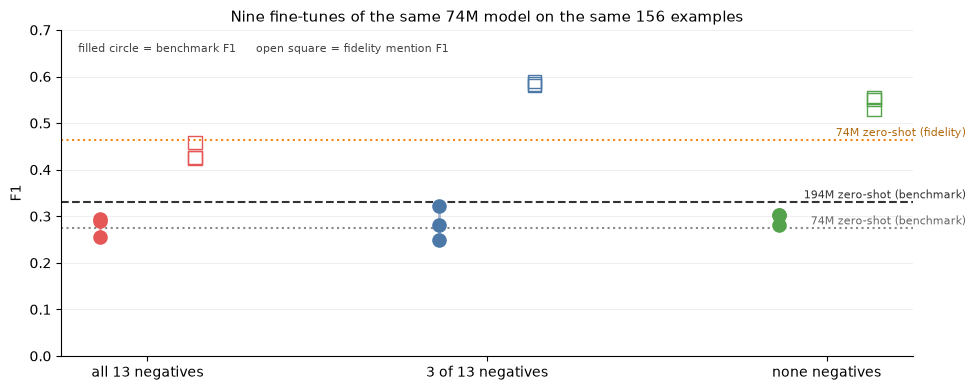

In [22]:
fig, ax = plt.subplots(figsize=(9.8, 4))
colours = {"all 13": "#E45756", "3 of 13": "#4C78A8", "none": "#54A24B"}
for i, (label, _) in enumerate(CONFIGS):
    rows = sweep[sweep.negatives == label]
    ax.scatter([i] * len(rows), rows["benchmark F1"], s=90, color=colours[label], zorder=3)
    ax.scatter([i + 0.28] * len(rows), rows["fidelity mention F1"], s=90, marker="s",
               facecolors="none", edgecolors=colours[label], zorder=3)
    ax.plot([i, i], [rows["benchmark F1"].min(), rows["benchmark F1"].max()],
            color=colours[label], lw=2, alpha=0.5)
ax.axhline(zs_f1, ls=":", color="#888")
ax.text(2.55, zs_f1 + 0.008, "74M zero-shot (benchmark)", fontsize=8, ha="right", color="#666")
ax.axhline(base_f1, ls="--", color="#333")
ax.text(2.55, base_f1 + 0.008, "194M zero-shot (benchmark)", fontsize=8, ha="right", color="#333")
ax.axhline(fid_ent["gliner2.5-small (74M, zero-shot)"].f1, ls=":", color="#F58518")
ax.text(2.55, fid_ent["gliner2.5-small (74M, zero-shot)"].f1 + 0.008,
        "74M zero-shot (fidelity)", fontsize=8, ha="right", color="#B26A0C")
ax.set_xticks([0.14, 1.14, 2.14])
ax.set_xticklabels([f"{c[0]} negatives" for c in CONFIGS])
ax.set_ylabel("F1"); ax.set_ylim(0, 0.7)
ax.set_title("Nine fine-tunes of the same 74M model on the same 156 examples", fontsize=11)
ax.spines[["top", "right"]].set_visible(False); ax.grid(alpha=0.2, axis="y")
ax.text(0.02, 0.96, "filled circle = benchmark F1     open square = fidelity mention F1",
        transform=ax.transAxes, fontsize=8, va="top", color="#444")
plt.tight_layout(); plt.show()

## 6. What the teacher cost, and what it would save

Distillation is an economic argument before it is a quality argument: pay once for labels, then run for free.
The one-off is measurable here; so is the recurring saving it is meant to buy.

In [23]:
# Cached responses still carry the cost they were billed at, so this is the real
# spend even on a warm cache -- llm.total_cost_usd would read $0 on a re-run.
from kgx.llm import _ontology_prompt

gen_cost   = sum(r.cost_usd for r in generated)
label_cost = sum(r.cost_usd for r in responses)
teacher_calls = llm.batch([_ontology_prompt(d["text"], ONT) for d in DOCUMENTS], workers=4)
per_doc_cost  = sum(r.cost_usd for r in teacher_calls) / len(DOCUMENTS)

one_off = gen_cost + label_cost
print(f"corpus synthesis   {len(generated):3} calls  ${gen_cost:.4f}")
print(f"chunk labelling    {len(responses):3} calls  ${label_cost:.4f}   "
      f"(${label_cost / max(len(labels), 1):.5f} per labelled chunk)")
print(f"one-off total                   ${one_off:.4f}  for {len(train_examples)} training examples")
print(f"\nteacher at inference            ${per_doc_cost:.4f} per document "
      f"(${per_doc_cost * 1000:.2f} per 1k documents)")
print(f"break-even                      {one_off / per_doc_cost:.0f} documents")

corpus synthesis     8 calls  $0.0639
chunk labelling     11 calls  $0.1852   ($0.00087 per labelled chunk)
one-off total                   $0.2490  for 170 training examples

teacher at inference            $0.0077 per document ($7.66 per 1k documents)
break-even                      33 documents


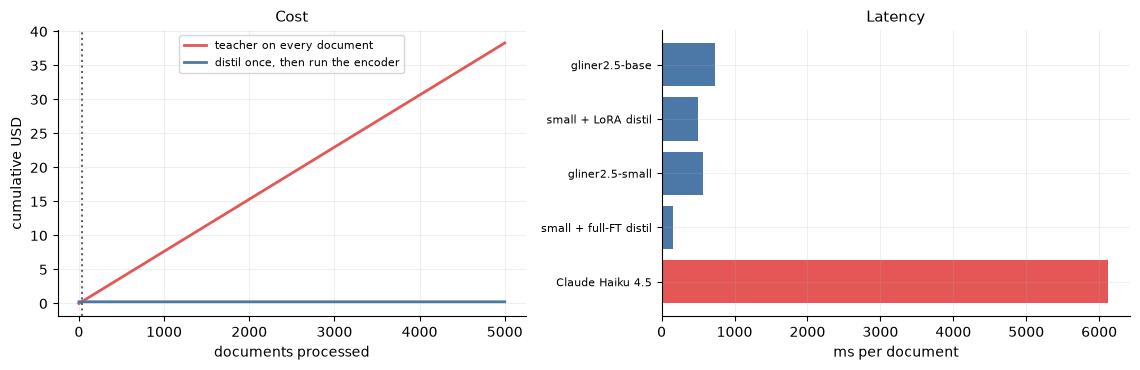

teacher latency through the CLI: 6116 ms/doc (subprocess overhead included)
encoder latency:                 163-728 ms/doc, CPU
training wall clock:             LoRA 66s, full fine-tune 94s on 170 examples x 8 epochs, CPU


In [24]:
import numpy as np

n = np.arange(0, 5001)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

axes[0].plot(n, n * per_doc_cost, lw=2, color="#E45756", label="teacher on every document")
axes[0].plot(n, np.full_like(n, one_off, dtype=float), lw=2, color="#4C78A8",
             label="distil once, then run the encoder")
axes[0].axvline(one_off / per_doc_cost, ls=":", color="#666")
axes[0].set_xlabel("documents processed"); axes[0].set_ylabel("cumulative USD")
axes[0].set_title("Cost", fontsize=11); axes[0].legend(fontsize=8)

order = [s for s in board.index if s in ms_per_doc]
teacher_ms = sum(r.duration_ms for r in teacher_calls) / len(teacher_calls)
labels_ = order + ["Claude Haiku 4.5 (teacher)"]
values  = [ms_per_doc[s] for s in order] + [teacher_ms]
axes[1].barh(range(len(values)), values,
             color=["#4C78A8"] * len(order) + ["#E45756"])
axes[1].set_yticks(range(len(values)))
axes[1].set_yticklabels([s.split(" (")[0] for s in labels_], fontsize=8)
axes[1].set_xlabel("ms per document"); axes[1].set_title("Latency", fontsize=11)
axes[1].invert_yaxis()

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

print(f"teacher latency through the CLI: {teacher_ms:.0f} ms/doc (subprocess overhead included)")
print(f"encoder latency:                 {min(ms_per_doc.values()):.0f}-{max(ms_per_doc.values()):.0f} ms/doc, CPU")
print(f"training wall clock:             LoRA {lora_wall:.0f}s, full fine-tune {full_wall:.0f}s "
      f"on {len(train_examples)} examples x {EPOCHS} epochs, CPU")

## 7. The scoreboard, once more

Everything measured, in one table. The distilled rows are the *mean over three seeds* of each configuration,
with the observed range beside them, because §5 showed that a single run is not a measurement. The two
reference rows — the 194M encoder you could download instead, and the teacher — are deterministic given the
cache, so they have no range.

The full fine-tune row is blank for a third reason. It is one run at seed 42 and its range was never
measured, so read it against the seed spreads in §5 rather than as a point.

In [25]:
zs      = bench["gliner2.5-small (74M, zero-shot)"]
base_zs = bench["gliner2.5-base (194M, zero-shot)"]
teacher = bench["Claude Haiku 4.5 (teacher)"]
best_cfg = summary.bench_mean.idxmax()
best_run = sweep["benchmark F1"].idxmax()

final = pd.DataFrame([
    {"system": "gliner2.5-small (74M, zero-shot)", "benchmark F1": round(zs.f1, 3), "range": "",
     "fidelity mention F1": round(fid_ent["gliner2.5-small (74M, zero-shot)"].f1, 3),
     "triples predicted": zs.n_predicted},
    *[{"system": f"  + LoRA distil, {label} negatives (3 seeds)",
       "benchmark F1": round(summary.loc[label, "bench_mean"], 3),
       "range": f"{summary.loc[label, 'bench_min']:.3f}-{summary.loc[label, 'bench_max']:.3f}",
       "fidelity mention F1": round(summary.loc[label, "fid_mean"], 3),
       "triples predicted": int(sweep[sweep.negatives == label]["benchmark predicted"].mean())}
      for label, _ in CONFIGS],
    {"system": "  + full fine-tune, all 13 negatives (1 seed)",
     "benchmark F1": round(bench["small + full-FT distil (74M)"].f1, 3), "range": "",
     "fidelity mention F1": round(fid_ent["small + full-FT distil (74M)"].f1, 3),
     "triples predicted": bench["small + full-FT distil (74M)"].n_predicted},
    {"system": "gliner2.5-base (194M, zero-shot)", "benchmark F1": round(base_zs.f1, 3), "range": "",
     "fidelity mention F1": round(fid_ent["gliner2.5-base (194M, zero-shot)"].f1, 3),
     "triples predicted": base_zs.n_predicted},
    {"system": "Claude Haiku 4.5 (teacher)", "benchmark F1": round(teacher.f1, 3), "range": "",
     "fidelity mention F1": 1.0, "triples predicted": teacher.n_predicted},
]).set_index("system")
display(final)

print(f"best single run anywhere in the sweep : {best_run}  F1 "
      f"{sweep.loc[best_run, 'benchmark F1']:.3f}")
print(f"best configuration by mean            : {best_cfg} negatives, "
      f"{summary.loc[best_cfg, 'bench_mean']:.3f} (range "
      f"{summary.loc[best_cfg, 'bench_min']:.3f}-{summary.loc[best_cfg, 'bench_max']:.3f})")
print(f"it has to clear                       : {zs.f1:.3f} (its own starting point) and "
      f"{base_zs.f1:.3f} (the 194M model it would replace)")
print(f"teacher ceiling                       : {teacher.f1:.3f}")

best_ms = sweep[sweep.negatives == best_cfg]["ms/doc"].mean()
print(f"\nlatency of that configuration         : {best_ms:.0f} ms/doc (mean of 3 seeds) against "
      f"{ms_per_doc['gliner2.5-base (194M, zero-shot)']:.0f} for the 194M model")
print(f"full fine-tune, for contrast          : "
      f"{ms_per_doc['small + full-FT distil (74M)']:.0f} ms/doc on "
      f"{bench['small + full-FT distil (74M)'].n_predicted} triples -- part of that speed is "
      "predicting less")

,benchmark F1,range,fidelity mention F1,triples predicted
system,,,,
"gliner2.5-small (74M, zero-shot)",0.275,,0.464,55
"+ LoRA distil, all 13 negatives (3 seeds)",0.280,0.255-0.295,0.436,48
"+ LoRA distil, 3 of 13 negatives (3 seeds)",0.284,0.250-0.322,0.585,75
"+ LoRA distil, none negatives (3 seeds)",0.295,0.281-0.303,0.545,79
"+ full fine-tune, all 13 negatives (1 seed)",0.242,,0.704,19
"gliner2.5-base (194M, zero-shot)",0.330,,0.523,68
Claude Haiku 4.5 (teacher),0.365,,1.000,112


best single run anywhere in the sweep : 3 of 13 / seed 99  F1 0.322
best configuration by mean            : none negatives, 0.295 (range 0.281-0.303)
it has to clear                       : 0.275 (its own starting point) and 0.330 (the 194M model it would replace)
teacher ceiling                       : 0.365

latency of that configuration         : 620 ms/doc (mean of 3 seeds) against 728 for the 194M model
full fine-tune, for contrast          : 163 ms/doc on 19 triples -- part of that speed is predicting less


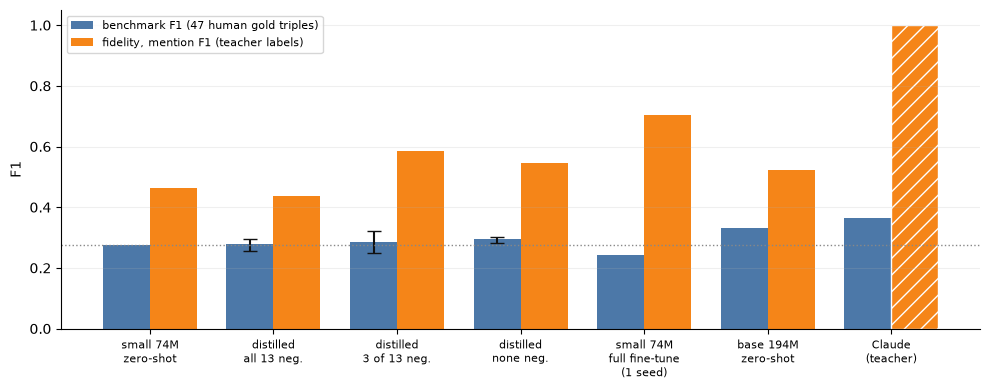

whiskers are the full range over three seeds, drawn only on the bars that have one; the full
fine-tune is a single run at seed 42 and the two reference rows are deterministic given the
cache. The dotted line is the 74M zero-shot starting point, and the teacher's fidelity bar is
1.0 by construction.


In [26]:
fig, ax = plt.subplots(figsize=(10, 4))
names, b_vals, f_vals, errs = ["small 74M\nzero-shot"], [zs.f1], \
    [fid_ent["gliner2.5-small (74M, zero-shot)"].f1], [(0.0, 0.0)]
for label, _ in CONFIGS:
    names.append(f"distilled\n{label} neg.")
    m = summary.loc[label, "bench_mean"]
    b_vals.append(m); f_vals.append(summary.loc[label, "fid_mean"])
    errs.append((m - summary.loc[label, "bench_min"], summary.loc[label, "bench_max"] - m))
names += ["small 74M\nfull fine-tune\n(1 seed)", "base 194M\nzero-shot", "Claude\n(teacher)"]
b_vals += [bench["small + full-FT distil (74M)"].f1, base_zs.f1, teacher.f1]
f_vals += [fid_ent["small + full-FT distil (74M)"].f1,
           fid_ent["gliner2.5-base (194M, zero-shot)"].f1, 1.0]
errs += [(0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]

x = list(range(len(names)))
ax.bar([i - 0.19 for i in x], b_vals, 0.38, color="#4C78A8", label="benchmark F1 (47 human gold triples)")
ax.bar([i + 0.19 for i in x], f_vals, 0.38, color="#F58518", label="fidelity, mention F1 (teacher labels)")
ax.bar([len(names) - 1 + 0.19], [1.0], 0.38, color="#F58518", hatch="//", edgecolor="white")
# Whiskers only where a range was measured: a zero-length bar on the single-seed
# fine-tune would read as a deterministic measurement, which it is not.
swept = list(range(1, 1 + len(CONFIGS)))
ax.errorbar([i - 0.19 for i in swept], [b_vals[i] for i in swept],
            yerr=[[errs[i][0] for i in swept], [errs[i][1] for i in swept]],
            fmt="none", ecolor="#111", capsize=5, lw=1.5)
ax.axhline(zs.f1, ls=":", color="#888", lw=1)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel("F1"); ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc="upper left"); ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.2, axis="y")
plt.tight_layout(); plt.show()

print("whiskers are the full range over three seeds, drawn only on the bars that have one; the full")
print("fine-tune is a single run at seed 42 and the two reference rows are deterministic given the")
print("cache. The dotted line is the 74M zero-shot starting point, and the teacher's fidelity bar is")
print("1.0 by construction.")

### What the numbers say

**Distillation worked. It just did not help.** The full fine-tune learned the teacher's labelling function
better than anything else measured here — mention fidelity 0.704 against 0.464 for the model it started from
and 0.523 for the 194M model — and then landed at **0.242** on the human benchmark against a 0.275 zero-shot
starting point. That 0.033 is one seed, and it sits well inside the 0.072 seed-only range §5 measures: read
it as no movement, not as a drop. The mechanism is in the triple counts, which are far too large to be noise.
It imitates the teacher and emits 19 canonical triples where the un-tuned model emits 55 and the teacher
emits 112, trading recall (0.298 down to 0.170) for precision (0.255 up to 0.421). Learning to reproduce a
teacher on the teacher's distribution is a different objective from getting better at the task, and here
fidelity moved 0.24 while the benchmark did not move at all.

**One fine-tuning run is not a measurement.** Three seeds of the `3 of 13` configuration span 0.250 to 0.322
on identical data. The gap this notebook set out to resolve — 74M zero-shot at 0.275 against 194M zero-shot
at 0.330 — is 0.056, smaller than that 0.072 seed range. Report seed 99 and distillation gained 0.047; report
seed 42 and it cost 0.025. Both are honest, and nothing in a single-run write-up tells the reader which one
they are looking at.

**The negatives decision moved fidelity and left the benchmark alone.** Declaring all 13 entity types on
every example, ten of them empty, was the defensible a-priori choice — it makes the training schema match the
inference schema — and it came last of the three at mean 0.280. Declaring none came first at 0.295, with the
tightest seed range (0.022) and 3 of 3 runs above the un-tuned model. That ordering is noise: the spread
between configuration means is 0.015, a fifth of the 0.072 worst-case seed range inside a single
configuration. Fidelity is the opposite case and is not close — mention F1 0.436 for all 13 against 0.585 for
three of 13, with within-configuration seed ranges of 0.033 and 0.008. How many negatives you declare has a
large, repeatable effect on how well the student imitates the teacher and no detectable effect on whether it
is a better extractor.

**Not one of the nine reaches the model you could have downloaded.** 0.295 mean for the best configuration
against 0.330 for `gliner2.5-base` zero-shot, and 0 of the 9 fine-tunes beat that line; the best single run
anywhere in the sweep is 0.322. $0.25 of teacher labels and about a minute of CPU training moved a 74M model
from 0.275 to 0.295 and left it 0.035 short. What that did buy is latency: 620 ms per document averaged over
the three `none` seeds against 728 for the 194M model, about 15%, measured on one pass over ten documents
with no warm-up.

**The ceiling is nine points above where you started and it is the teacher's.** Claude Haiku scores 0.365 on
this benchmark and `gliner2.5-base` scores 0.330. Distillation transfers *teacher behaviour*, so a student
cannot pass the row it is imitating, and here that row is 0.035 above a free encoder. The interesting
distillation setups are the ones where the teacher is far ahead of every small model — that is what makes the
NVIDIA-style curve worth climbing, and it is not the situation on this corpus.

**`eval_loss` will not pick the run for you.** Its *level* is not comparable across the three configurations:
the boundary head reduces by `sum`, so the figure scales with how many entity queries an example declares —
13, about five, about two. The pooled rho over all nine runs is −0.09, which is nothing, and it would not
have meant anything had it been larger: pooling correlates F1 against that offset. Inside a configuration,
where the comparison is fair, the three seeds give +0.50, +0.00 and +1.00. Not weak: the wrong sign. In
`none` the rank correlation is a clean +1.00, the run with the *lowest* eval loss (166.6) being the worst of
the three on the benchmark (0.281) and the highest (169.8) the best (0.303). Whether `save_best=True` and `metric_for_best="eval_loss"` pick a better *epoch*
than simply stopping is a separate question this notebook does not answer — every model scored above is
`final`, the last epoch — but across runs, the quantity being minimised is not the quantity you care about.

**The economics were never the problem.** The teacher cost $0.2490 once — 8 calls to write the corpus, 11 to
label 213 chunks at $0.00087 each — against $0.0077 per document at inference. Break-even is 33 documents,
and the encoder runs 163–728 ms per document on CPU against 6.1 s through the CLI. Read both timing numbers
loosely: the 6.1 s is replayed from the response cache rather than measured live, and the 163 ms floor
belongs to the full fine-tune, which is fast partly because it emits half as many mentions as the model it
started from. Every part of the cost argument in `docs/LANDSCAPE.md` holds. It is the quality half that does
not, at this data scale.

**And notebook 03's caveat bounds all of it.** 47 gold triples do not exhaust ten documents, so precision
here is a lower bound and the systems that emit more triples are penalised for volume as well as for error.
The teacher's 0.259 precision is the clearest symptom. Read the recall column with more trust than the
precision column, and read both as a comparison between systems rather than as an absolute.

### Where to take it

**More data, and a scaling curve instead of a point.** 170 examples is three to four orders of magnitude
below the 10⁵–10⁶ documents the blueprint describes. The experiment that would actually settle this is 50 / 150 / 500 / 2000
examples at three seeds each, plotting the seed band as well as the mean, and finding the point where the
band narrows below the effect. Everything in this notebook says that point is well to the right of where it
stops.

**A better teacher, or a pooled one.** Haiku at 0.365 is a weak ceiling. Sonnet would raise it; so would
using notebook 03's escalation pipeline as the labeller instead of a single model, or having two models label
and adjudicating the disagreements. Distilling from an ensemble is the standard move and none of it is tried
here.

**Human-adjudicated labels, which would also fix the benchmark.** The same pooled-adjudication pass that
notebook 03 asks for — take the union of what every system produced, judge each triple once, score against
the pool — would give both better training labels and a benchmark whose precision column means something.
That single piece of work would improve every notebook in this repo that scores triples.

**Model selection that tracks the task.** `gliner2.training.metrics` ships `f1_from_counts`,
`exact_span_counts` and `gold_from_target_graphs`. Wiring those into `compute_metrics` and setting
`metric_for_best` to a real F1 with `greater_is_better=True` would at least select on the right quantity —
though on this evidence it would still be selecting from a very noisy distribution.

**Freeze more of the model.** Only `encoder_lr=1e-5` / `task_lr=5e-4` and LoRA r=16 were tried. A frozen
encoder with only the boundary and relation heads trained, or a much smaller task learning rate, is the
obvious way to get the fidelity gain without the recall collapse the full fine-tune showed — 19 triples
from ten documents where the same model zero-shot produced 55.

**Relation negatives.** Entity types can be declared absent; relation types cannot, so the model faces all
15 relation queries at inference having only ever trained on the one or two present in each chunk. Emitting
raw `{"input", "output"}` records rather than `InputExample`, with a relation carrying an explicitly empty
instance list, may be expressible at the JSONL level even though the dataclass rejects it. Worth an hour.

**Distil into something smaller than the student.** The premise that makes distillation compelling elsewhere
is a large gap between teacher and student cost. Here the student is already 74M and free. The version of
this experiment with real stakes distils into something that runs at a thousand documents a second — a
linear-chain tagger, or spaCy's `en_core_web_sm` pipeline — where a 0.03 F1 loss buys two orders of magnitude.

In [27]:
kept = RUNS / "lora_merged"
for path in sorted(RUNS.iterdir()):
    if path.is_dir() and path != kept:
        shutil.rmtree(path)
print(f"kept {kept.relative_to(ROOT)} "
      f"({sum(p.stat().st_size for p in kept.rglob('*') if p.is_file()) / 1e6:.0f} MB); "
      f"deleted the other run directories.")
print(f"\nLLM spend recorded for this notebook: ${gen_cost + label_cost:.4f} "
      f"({llm.n_calls} live calls this run, {llm.n_cached} from cache)")
print(f"cache: {len(list(llm.cache_dir.glob('*.json')))} responses in {llm.cache_dir}")
print("delete that directory to force a genuine re-run -- the synthetic corpus is regenerated,")
print("so the training data changes and every number from section 4 onward moves.")

kept output/distill/lora_merged (304 MB); deleted the other run directories.

LLM spend recorded for this notebook: $0.2490 (0 live calls this run, 39 from cache)
cache: 36 responses in output/llm_cache
delete that directory to force a genuine re-run -- the synthetic corpus is regenerated,
so the training data changes and every number from section 4 onward moves.
